In [1]:
# Notebook for the exploration of the Progressive Multitask Classifier model

In [2]:
# Importing the packages needed to run the model

import deepchem as dc
from rdkit import Chem
from rdkit.Chem import Draw
import tensorflow as tf

import pandas as pd

from matplotlib import pyplot as plt

import numpy as np

from sklearn import metrics
from sklearn.metrics import f1_score

In [3]:
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer='ECFP', 
    splitter='random')

train_dataset, valid_dataset, test_dataset = datasets

In [22]:
SR_train_dataset = dc.data.DiskDataset.from_numpy(
    train_dataset.X, # take all of X
    train_dataset.y[:,7:], # take only answers from 7 onwards
    w=np.ones((len(train_dataset.X), 5)), # this is set up for the balancing of the data set so that the toxic molecules are given more inportance
    ids=train_dataset.ids, # all ids
    tasks=train_dataset.tasks[7:]) # and only task labels from 7 onwards

SR_valid_dataset = dc.data.DiskDataset.from_numpy(
    valid_dataset.X,
    valid_dataset.y[:,7:],
    w=np.ones((len(valid_dataset.X), 5)),
    ids=valid_dataset.ids,
    tasks=valid_dataset.tasks[7:])

SR_test_dataset = dc.data.DiskDataset.from_numpy(
    test_dataset.X,
    test_dataset.y[:,7:],
    w=np.ones((len(test_dataset.X), 5)),
    ids=test_dataset.ids,
    tasks=test_dataset.tasks[7:])

# This transforms the dataset to try to deal with the unbalanced classes
transformer = dc.trans.BalancingTransformer(dataset=SR_train_dataset)
SR_train_dataset = transformer.transform(SR_train_dataset)

transformer = dc.trans.BalancingTransformer(dataset=SR_valid_dataset)
SR_valid_dataset = transformer.transform(SR_valid_dataset)

transformer = dc.trans.BalancingTransformer(dataset=SR_test_dataset)
SR_test_dataset = transformer.transform(SR_test_dataset)

In [27]:
# this loads in a general purpose regression model
model = dc.models.ProgressiveMultitaskClassifier(
    n_tasks=len(SR_test_dataset.tasks), # size of y, we have one output task here: finding toxicity
    n_features=len(SR_test_dataset.X[0]), # number of input features
    layer_sizes=[1000],
    dropouts=0.5)

############################################
# Now we fit the training dataset!         #
############################################
model.fit(SR_train_dataset, nb_epoch=10)

In [31]:
params_dict = {
    'n_tasks': [len(SR_test_dataset.tasks)],
    'n_features': [len(SR_test_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'weight_init_stddevs' : [0.02, 0.05]
    
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.ProgressiveMultitaskClassifier)
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
        params_dict, SR_train_dataset, SR_valid_dataset, metric, transformers)

In [32]:
all_results

{'_dropouts_0.200000_layer_sizes[500]_n_features_1024_n_tasks_5_weight_init_stddevs_0.020000': 0.5980475076570735,
 '_dropouts_0.200000_layer_sizes[500]_n_features_1024_n_tasks_5_weight_init_stddevs_0.050000': 0.6139096506219902,
 '_dropouts_0.500000_layer_sizes[500]_n_features_1024_n_tasks_5_weight_init_stddevs_0.020000': 0.6069440512444169,
 '_dropouts_0.500000_layer_sizes[500]_n_features_1024_n_tasks_5_weight_init_stddevs_0.050000': 0.5881178480481147,
 '_dropouts_0.200000_layer_sizes[1000]_n_features_1024_n_tasks_5_weight_init_stddevs_0.020000': 0.5438536400465738,
 '_dropouts_0.200000_layer_sizes[1000]_n_features_1024_n_tasks_5_weight_init_stddevs_0.050000': 0.5425529319076381,
 '_dropouts_0.500000_layer_sizes[1000]_n_features_1024_n_tasks_5_weight_init_stddevs_0.020000': 0.545450999729544,
 '_dropouts_0.500000_layer_sizes[1000]_n_features_1024_n_tasks_5_weight_init_stddevs_0.050000': 0.5751794949959621,
 '_dropouts_0.200000_layer_sizes[1000, 1000]_n_features_1024_n_tasks_5_weight

In [33]:
# Dataset scores using ROC AUC metric:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)

print('Over all tasks:')
print("Training set score:", model.evaluate(SR_train_dataset, [metric], transformers))
print("Valid set score:", model.evaluate(SR_valid_dataset, [metric], transformers))
print("Test set score:", model.evaluate(SR_test_dataset, [metric], transformers))
ground_truth = SR_test_dataset.y
predictions = model.predict(SR_test_dataset)
metric = dc.metrics.roc_auc_score
print('Per task:')
print('Task\t\tROC AUC')
for i in range(len(SR_test_dataset.tasks)):
    score = metric(dc.metrics.to_one_hot(ground_truth[:,i]), predictions[:,i])
    print('{:}\t\t{:.3}'.format(SR_test_dataset.tasks[i],score))

Over all tasks:
Training set score: {'roc_auc_score': 0.5761122580860422}
Valid set score: {'roc_auc_score': 0.5465890858277007}
Test set score: {'roc_auc_score': 0.560516182480478}
Per task:
Task		ROC AUC
SR-ARE		0.729
SR-ATAD5		0.531
SR-HSE		0.524
SR-MMP		0.498
SR-p53		0.521


Text(0.5, 1.0, 'SR-ARE')

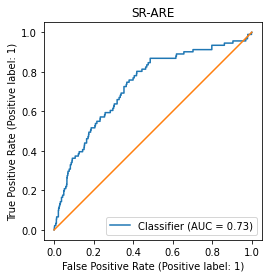

In [29]:
task_number = 0
metrics.RocCurveDisplay.from_predictions(ground_truth[:,task_number], predictions[:,task_number][:,1])
plt.plot([0,1], [0,1])
plt.axis('square')
plt.title(SR_test_dataset.tasks[task_number])

In [30]:
print("F1 Score:")
f1_score(ground_truth[:,task_number], [round(x) for x in predictions[:,task_number][:,1]], average='binary')

F1 Score:


0.3142857142857142